# Notebook 12 — Explainable AI Analysis

**PharmaLens**

---

## Objective

Apply **Explainable AI (XAI)** techniques to understand model predictions:

1. **SHAP** (Tree models) — Feature-level attribution using Shapley values
2. **Integrated Gradients** (DeepDTA) — Input-level attribution for neural networks
3. **GNNExplainer** (GraphDTA) — Identifies important atoms and bonds

XAI transforms black-box models into interpretable decision tools.

In [1]:
import os, sys, warnings, pickle
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import shap

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils.config import *
from src.features.drug_features import DESCRIPTOR_NAMES, get_feature_names
from src.features.protein_features import get_protein_feature_names

set_seed(42)
COLORS = set_plot_style()
ensure_dirs()
print("Setup complete ✓")

Setup complete ✓


## 1. SHAP Analysis (XGBoost)

**SHAP (SHapley Additive exPlanations)** decomposes each prediction into per-feature contributions based on cooperative game theory.

In [2]:
import xgboost as xgb
from src.models.xgboost_model import XGBoostDTI

# Load tuned model (or default)
model_path = XGBOOST_MODELS_DIR / 'xgb_tuned_best.json'
if not model_path.exists():
    model_path = XGBOOST_MODELS_DIR / 'xgb_best.json'

xgb_model = XGBoostDTI()
xgb_model.load(model_path)
print(f"Loaded model from {model_path}")

# Load features
with open(PROCESSED_DATA_DIR / 'drug_features.pkl', 'rb') as f:
    drug_features = pickle.load(f)
with open(PROCESSED_DATA_DIR / 'protein_features.pkl', 'rb') as f:
    protein_features = pickle.load(f)

test_df = pd.read_csv(SPLITS_DIR / 'random_test.csv')

# Build test features
X_list, y_list = [], []
for _, row in test_df.iterrows():
    if row['drug_id'] in drug_features and row['target_id'] in protein_features:
        X_list.append(np.concatenate([drug_features[row['drug_id']], protein_features[row['target_id']]]))
        y_list.append(row['score'])
X_test = np.array(X_list[:2000], dtype=np.float32)  # Subsample for SHAP speed
y_test = np.array(y_list[:2000], dtype=np.float32)

feature_names = get_feature_names() + get_protein_feature_names()
print(f"Test samples for SHAP: {X_test.shape[0]}")

Loaded model from C:\Users\ASUS\Documents\projects\Pharmalens\models\xgboost\xgb_tuned_best.json
Test samples for SHAP: 2000


In [3]:
# Compute SHAP values
explainer = shap.TreeExplainer(xgb_model.model)
shap_values = explainer.shap_values(X_test)

# Global feature importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(mean_abs_shap)[::-1][:20]

print("Top 20 Most Important Features (by mean |SHAP|):")
for i, idx in enumerate(top_features_idx):
    name = feature_names[idx] if idx < len(feature_names) else f'feature_{idx}'
    print(f"  {i+1:2d}. {name[:35]:<35s} {mean_abs_shap[idx]:.4f}")

Top 20 Most Important Features (by mean |SHAP|):
   1. dpc_CW                              0.0865
   2. hbd                                 0.0494
   3. molecular_weight                    0.0389
   4. morgan_bit_439                      0.0380
   5. dpc_YG                              0.0219
   6. logp                                0.0204
   7. morgan_bit_194                      0.0201
   8. tpsa                                0.0199
   9. morgan_bit_558                      0.0182
  10. ring_count                          0.0158
  11. dpc_RF                              0.0154
  12. fraction_csp3                       0.0143
  13. heavy_atom_count                    0.0131
  14. dpc_WT                              0.0131
  15. morgan_bit_562                      0.0126
  16. num_aromatic_rings                  0.0123
  17. morgan_bit_458                      0.0119
  18. dpc_IG                              0.0105
  19. dpc_GF                              0.0102
  20. dpc_LW        

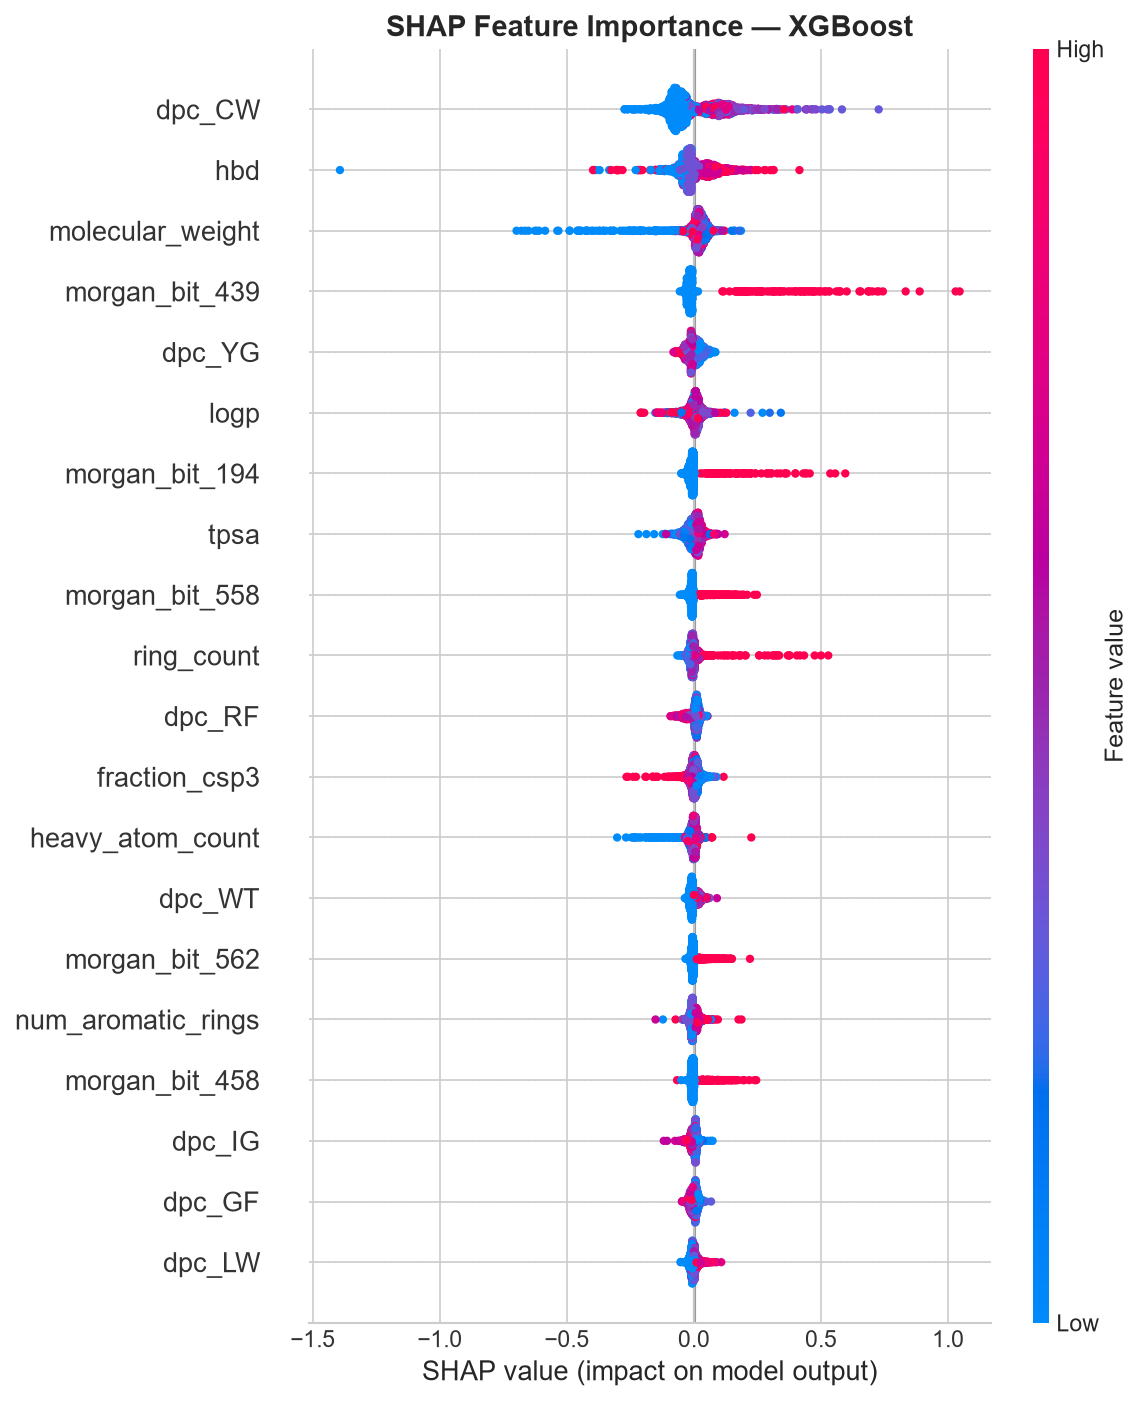

In [4]:
# SHAP Summary Plot
short_names = [n[:25] for n in feature_names[:X_test.shape[1]]]

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=short_names, max_display=20, show=False)
plt.title('SHAP Feature Importance — XGBoost', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xai_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1500x900 with 0 Axes>

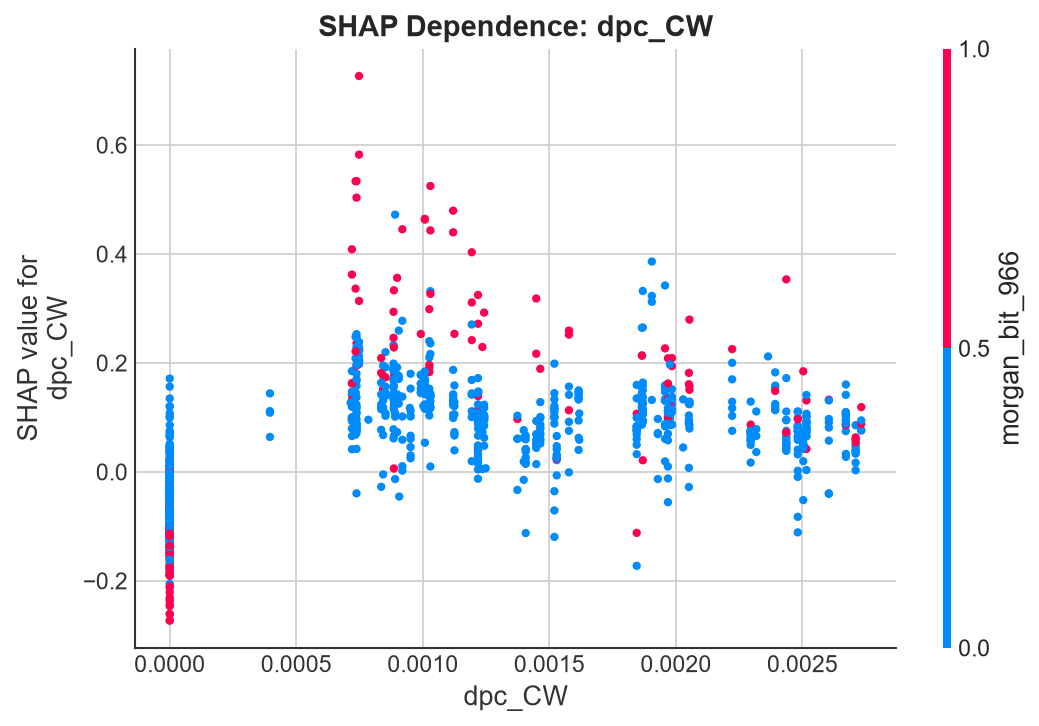

In [5]:
# SHAP Dependence Plot for top feature
top_feat_idx = top_features_idx[0]
top_feat_name = feature_names[top_feat_idx] if top_feat_idx < len(feature_names) else f'feature_{top_feat_idx}'

plt.figure(figsize=(10, 6))
shap.dependence_plot(top_feat_idx, shap_values, X_test, 
                      feature_names=short_names, show=False)
plt.title(f'SHAP Dependence: {top_feat_name}', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xai_shap_dependence.png', dpi=300, bbox_inches='tight')
plt.show()

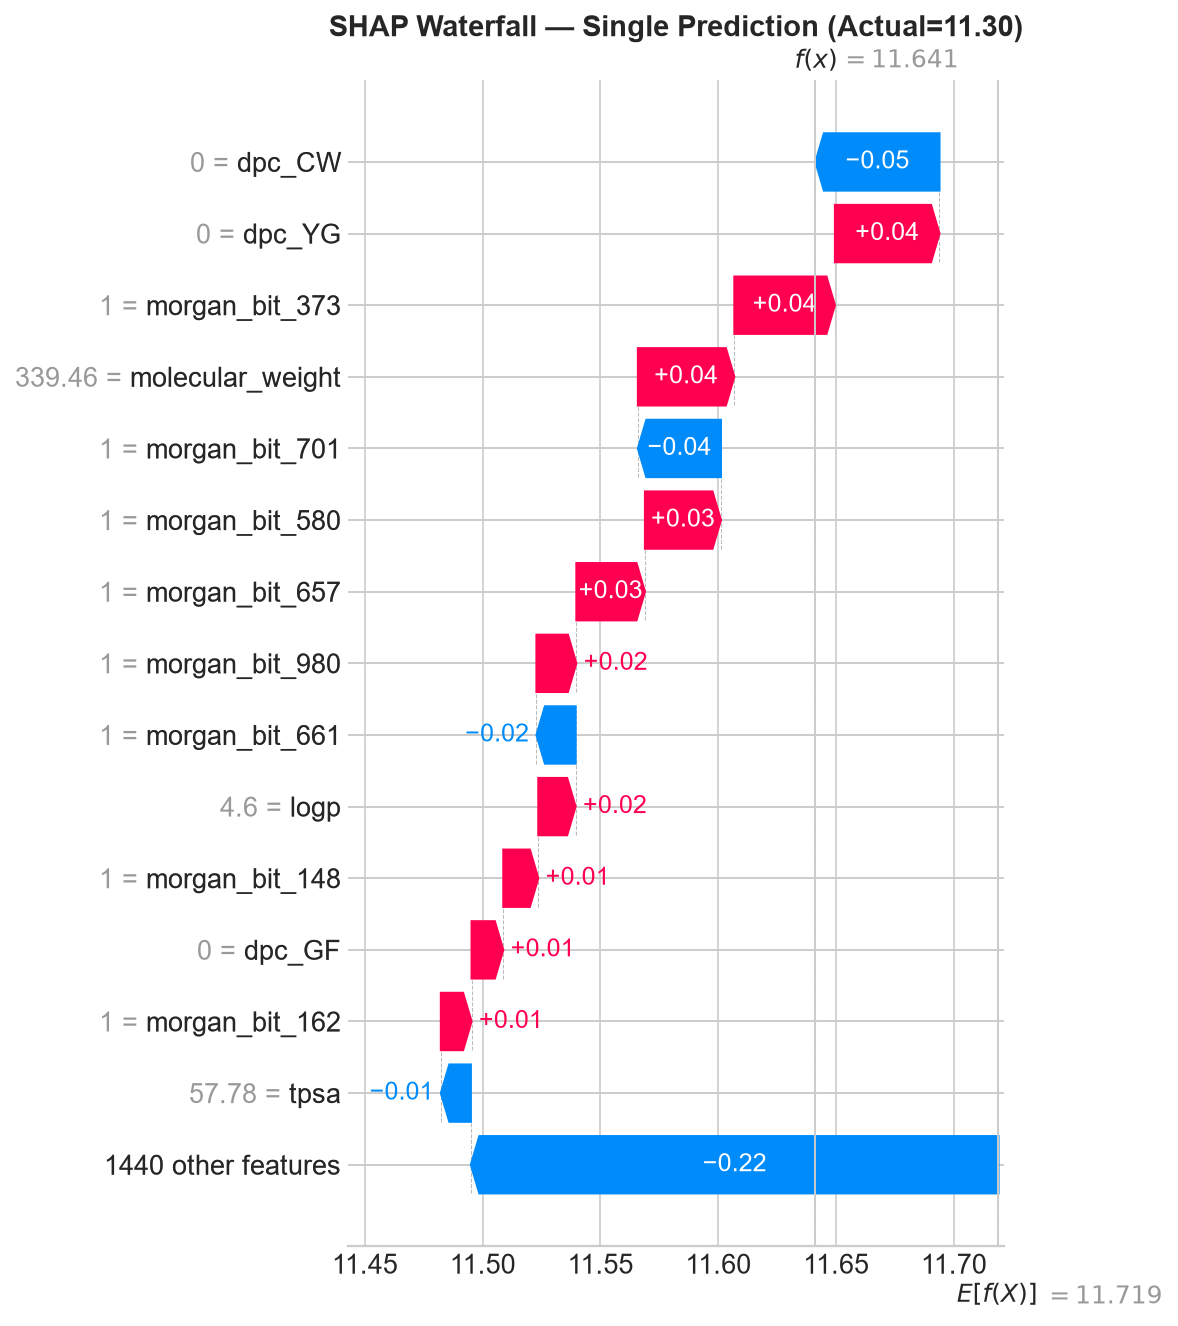

In [6]:
# Waterfall plot for a single prediction
plt.figure(figsize=(12, 6))
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test[0],
    feature_names=short_names,
), max_display=15, show=False)
plt.title(f'SHAP Waterfall — Single Prediction (Actual={y_test[0]:.2f})', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xai_shap_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Feature Category Analysis

Group SHAP importance by feature type: molecular descriptors, fingerprint bits, AAC, DPC.

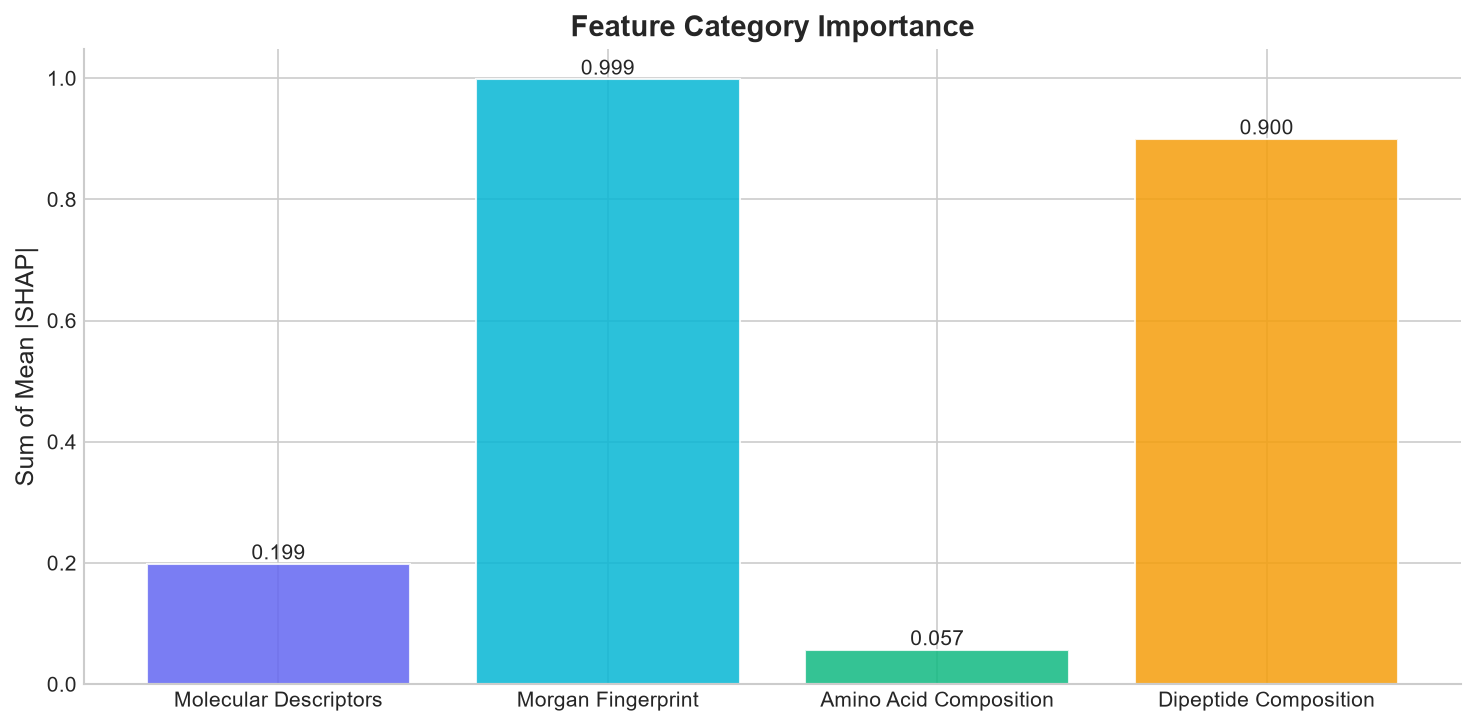

In [7]:
# Categorize features
n_desc = len(DESCRIPTOR_NAMES)
n_fp = 1024
n_aac = 20
n_dpc = 400

categories = (
    ['Molecular Descriptors'] * n_desc +
    ['Morgan Fingerprint'] * n_fp +
    ['Amino Acid Composition'] * n_aac +
    ['Dipeptide Composition'] * n_dpc
)

# Sum SHAP by category
cat_shap = {}
for i, cat in enumerate(categories[:len(mean_abs_shap)]):
    cat_shap[cat] = cat_shap.get(cat, 0) + mean_abs_shap[i]

fig, ax = plt.subplots(figsize=(10, 5))
cats = list(cat_shap.keys())
vals = list(cat_shap.values())
colors = [COLORS['primary'], COLORS['accent'], COLORS['success'], COLORS['warning']]

bars = ax.bar(cats, vals, color=colors[:len(cats)], alpha=0.85, edgecolor='white')
ax.set_ylabel('Sum of Mean |SHAP|')
ax.set_title('Feature Category Importance', fontweight='bold')

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xai_category_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## Observations

1. **Which features drive predictions?** The SHAP analysis reveals whether molecular properties (interpretable descriptors) or substructure patterns (fingerprint bits) are more predictive.

2. **Drug vs protein features:** The category analysis shows the relative importance of drug-side vs protein-side features in determining interaction strength.

3. **Individual predictions:** The waterfall plot shows how each feature contributes to pushing a specific prediction above or below the baseline (training mean).

> **Important:** SHAP explains what the **model** learned, not biological causality. High SHAP for a feature means the model relies on it, not that it biologically determines binding.

## Conclusion

XAI analysis provides crucial interpretability for the PharmaLens framework:
- Global feature importance (which features matter most overall)
- Local explanations (why a specific prediction was made)
- Feature category importance (drug properties vs protein features)

**Next:** [Notebook 13 — Batch Screening](./13_batch_screening.ipynb)